# Introduction

In [80]:
##Different Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from functionsFolder.config import text_data, biometric_data, adv_to_del, team_to_del, id, useless, index, to_keep
from functionsFolder.preProcessingAuto import preprocess_working_df
from functionsFolder.modelAutomation import get_features_and_target, clean_features, evaluate_models, prepare_features
from sklearn.feature_selection import SelectPercentile
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from time import time
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
import joblib

##Different Paths
HOME = r"C:\Users\Utilisateur\Desktop\Master ULB\Mémoire"
W_DB = r"\Database\Working db"
STACK = r"\Thesis - Code\database\Database Updates\Database stack"

In [81]:
base_df = pd.read_excel(HOME + STACK + r"\looping_df_1746884524.8275206.xlsx")
RECOVERY_OPP = HOME + W_DB + r"\Features\Team data\27-4-2025_team.xlsx"

# Preprocessing

In [ ]:
#add the mean of every position in the advance part and scouting evaluation part
base_df[to_keep['adv']] = base_df[to_keep['adv']].fillna(base_df.groupby('Pos_x_features')[to_keep['adv']].transform('median'))
base_df[to_keep['scouting_reports']] = base_df[to_keep['scouting_reports']].fillna(base_df.groupby('Pos_x_features')[to_keep['scouting_reports']].transform('median'))
processed_df = preprocess_working_df(base_df, recovery_file=RECOVERY_OPP)
#Get a copy of the dataset
working_df = processed_df.copy()
# Get initial features and targets
raw_features, target = get_features_and_target(working_df) #Get the features and target columns' name in separate lists


# Step 2: Prepare feature list (optionally re-adding 'adv' and 'scouting_reports')
include_subsets = ['per_40', 'team', 'opp', 'adv', 'scouting_reports']
features, included_types = prepare_features( #prepare the features' space
    base_features=raw_features,
    df=working_df,
    useless_list=useless, #list of features that we do not use 
    feature_dict=to_keep, #dictionnary of the features that we keep 
    include_keys=include_subsets #the keys to the dictionnary above
)
#Change the height from feet to inches 
working_df['Height_features'] = working_df['Height_features'].apply(
    lambda x: int(x.split('-')[0]) * 12 + int(x.split('-')[1])
)

#We keep only the players that where drafted after 2009 (60 players for 15 years = 900 max)
df = working_df[working_df['draft_season_features'] > 8].copy()
i = 1
df['med_tresh'] = (df[f'WS/48-{i}_target'] > 0).astype(int)

#We keep context variables in an list
keywords = ['team', 'opp', 'text']
filtered_list = [element for element in features if not any(keyword in element for keyword in keywords)]

#df[features].to_excel('df_for_final.xlsx', index=False)

# Data Analysis

## Height

In [13]:
df['Height_features']*2.54

1       205.74
3       198.12
4       198.12
5       185.42
6       203.20
         ...  
1248    195.58
1249    203.20
1250    200.66
1251    203.20
1252    193.04
Name: Height_features, Length: 912, dtype: float64

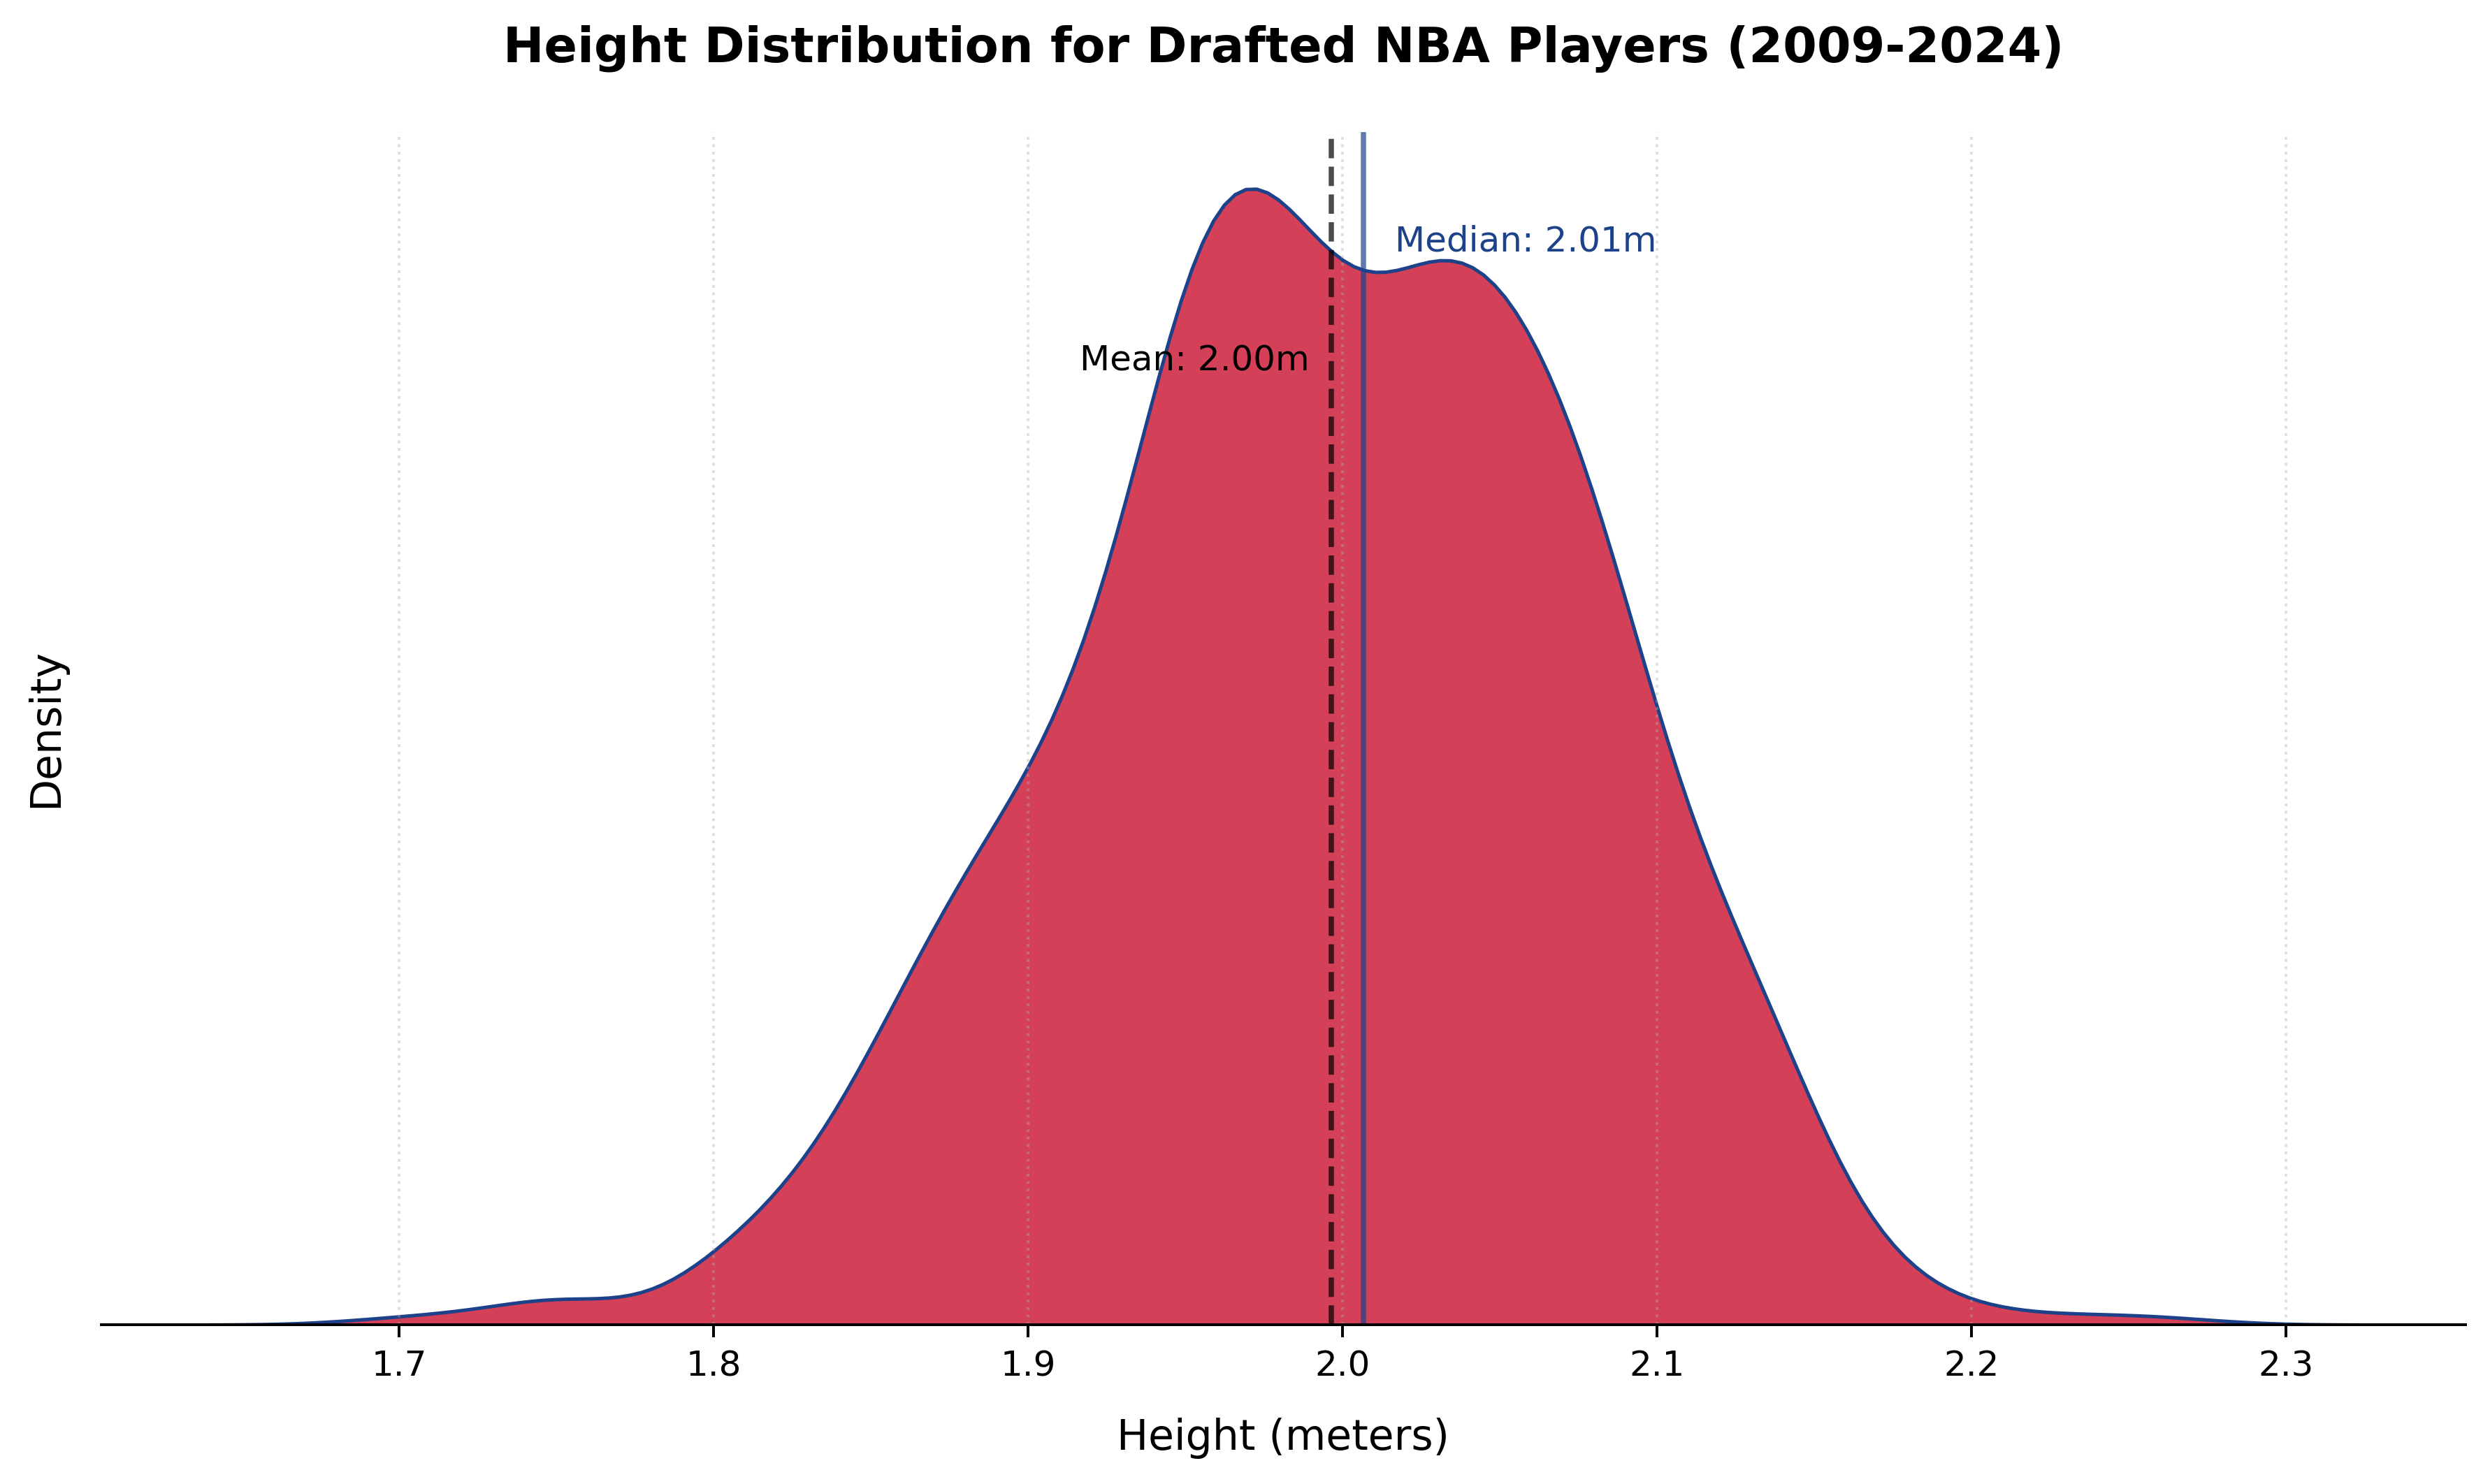

In [74]:
plt.figure(figsize=(10, 6), dpi=360, facecolor='white')  # Light gray background

# NBA-inspired styling
nba_palette = ['#1D428A', '#C8102E', '#FDB927', '#000000', '#007A33']
court_color = '#F5F5F5'
main_color = nba_palette[1]  # Bulls Red
secondary_color = nba_palette[0]  # Lakers Gold

# Create the plot with enhanced parameters
ax = sns.kdeplot(df['Height_features']*0.0254, 
                fill=True, 
                color=main_color,
                alpha=0.8,
                linewidth=1,
                edgecolor=secondary_color)

# Add mean and median lines
mean_height = df['Height_features'].mean()*0.0254
median_height = df['Height_features'].median()*0.0254
plt.axvline(mean_height, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axvline(median_height, color=secondary_color, linestyle='-', linewidth=1.5, alpha=0.7)

# Add annotations
plt.text(mean_height-0.08, ax.get_ylim()[1]*0.8, f'Mean: {mean_height:.2f}m', 
         fontsize=10, color='black')
plt.text(median_height+0.01, ax.get_ylim()[1]*0.9, f'Median: {median_height:.2f}m', 
         fontsize=10, color=secondary_color)

# Style enhancements
plt.title('Height Distribution for Drafted NBA Players (2009-2024)', 
          fontsize=14, fontweight='bold', pad=20, color='black')
plt.xlabel('Height (meters)', fontsize=12, labelpad=10)
plt.ylabel('Density', fontsize=12, labelpad=10)
plt.yticks([])

# Customize spines and grid
sns.despine(left=True)
plt.grid(axis='x', linestyle=':', alpha=0.4)


plt.tight_layout()
plt.show()

## Wordcloud

In [79]:
word = r"C:\Users\Utilisateur\Desktop\Master ULB\Mémoire\Database\Working db\Features\Scouting report\Scouting reports - Copie (2).xlsx"
wordcloud = pd.read_excel(word, sheet_name='Scouting Report 2006-2025')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Utilisateur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


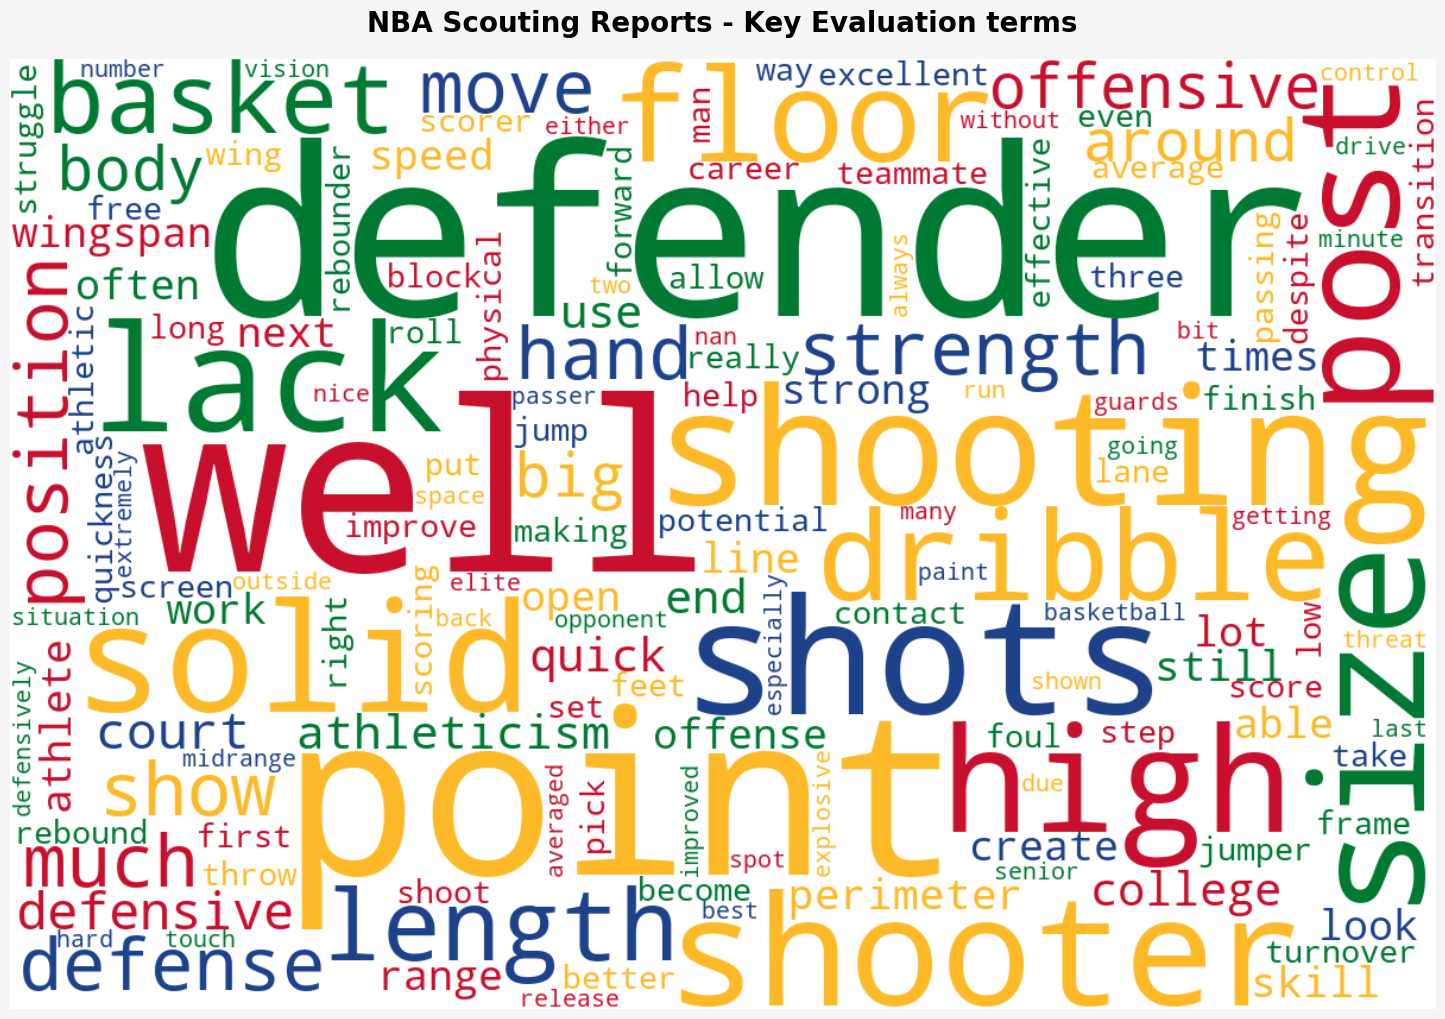

In [ ]:
from wordcloud import WordCloud, STOPWORDS
from nltk.corpus import stopwords
import re

# First, ensure you have NLTK stopwords
import nltk
nltk.download('stopwords')

text = wordcloud['Weakness'] + wordcloud['Strength']

## Step 1: Prepare Custom Stopwords
# Basic English stopwords
base_stopwords = set(stopwords.words('english'))

# Basketball-specific stopwords
basketball_stopwords = {
    'player', 'players', 'game', 'games', 'ability', 'can', 'one', 'will',
    'team', 'teams', 'play', 'plays', 'played', 'playing', 'nba', 'draft',
    'good', 'great', 'make', 'makes', 'like', 'get', 'gets', 'need', 'needs',
    'time', 'year', 'years', 'old', 'pro', 'professional', 'level', 'combine', 'season',
    'guard', 'shot', 'ball', 'rim', 'hes', 'per', 'doesnt'
}

# Combine with WordCloud's default stopwords
all_stopwords = base_stopwords.union(basketball_stopwords).union(STOPWORDS)

## Step 2: Text Processing Function
def process_text(text):
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))
    # Convert to lowercase
    text = text.lower()
    return text

## Step 3: Prepare Text Data
# Combine all scouting reports
all_text = ' '.join(text.apply(process_text).dropna())

## Step 4: Generate Word Cloud
wordcloud = WordCloud(
    width=1200,
    height=800,
    background_color='white',
    stopwords=all_stopwords,
    colormap='Reds',  # NBA red theme
    max_words=150,
    contour_width=3,
    contour_color='#1D428A',  # NBA blue
    collocations=False,  # Don't show word pairs
    prefer_horizontal=0.9,
    min_font_size=8,
    max_font_size=200,
    relative_scaling=0.5
).generate(all_text)

## Step 5: Visualization
plt.figure(figsize=(16, 10), facecolor='#F5F5F5')
plt.imshow(wordcloud.recolor(color_func=nba_color_func, random_state=3), interpolation='bilinear')
plt.axis('off')
plt.title('NBA Scouting Reports - Key Evaluation terms', 
         fontsize=20, pad=20, color='black', fontweight='bold')
plt.tight_layout(pad=0)
plt.show()

## Boxplot Per 40

In [125]:
df['advanced_OWS_features']

1       2.1
3       2.5
4       1.5
5       3.7
6       0.7
       ... 
1248    3.3
1249   -0.2
1250    5.5
1251    1.7
1252    4.0
Name: advanced_OWS_features, Length: 912, dtype: float64

In [132]:
per40_cols = ['per_40_PTS_features',
'per_40_AST_features',
'per_40_ORB_features',
'per_40_DRB_features',
'per_40_TRB_features',
'per_40_STL_features',
'per_40_BLK_features',
'per_40_TOV_features',
'per_40_PF_features',
'per_40_3P_features',
'per_40_3PA_features',
'per_40_2P_features',
'per_40_2PA_features',
'per_40_FT_features',
'per_40_FTA_features',
'advanced_OWS_features',
'advanced_DWS_features',
'advanced_WS_features',
'advanced_WS/40_features']

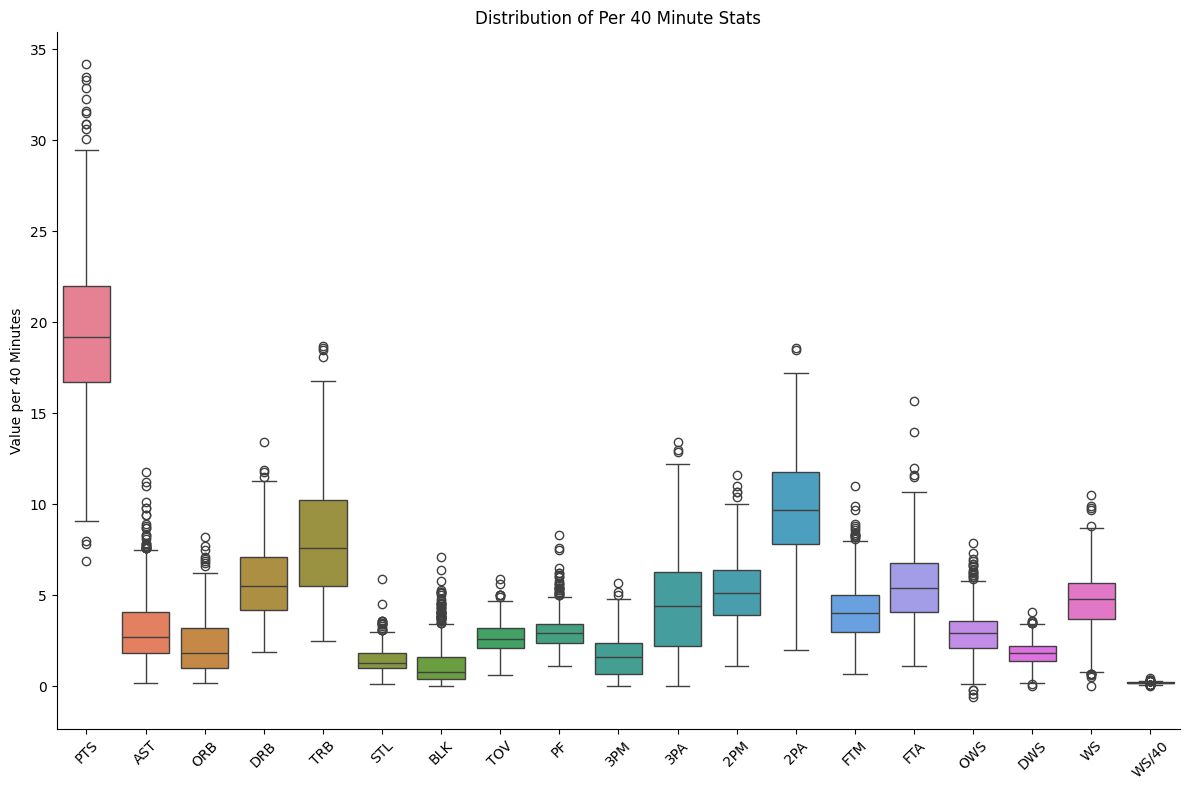

In [133]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[per40_cols])
plt.title('Distribution of Per 40 Minute Stats')
plt.xticks(per40_cols,['PTS',  'AST',
             'ORB', 'DRB', 'TRB',  'STL', 'BLK', 
            'TOV', 'PF', '3PM', '3PA', '2PM', '2PA','FTM', 'FTA','OWS', 'DWS', 'WS', 'WS/40'], rotation=45)
plt.ylabel('Value per 40 Minutes')
sns.despine()
plt.tight_layout()
plt.show()

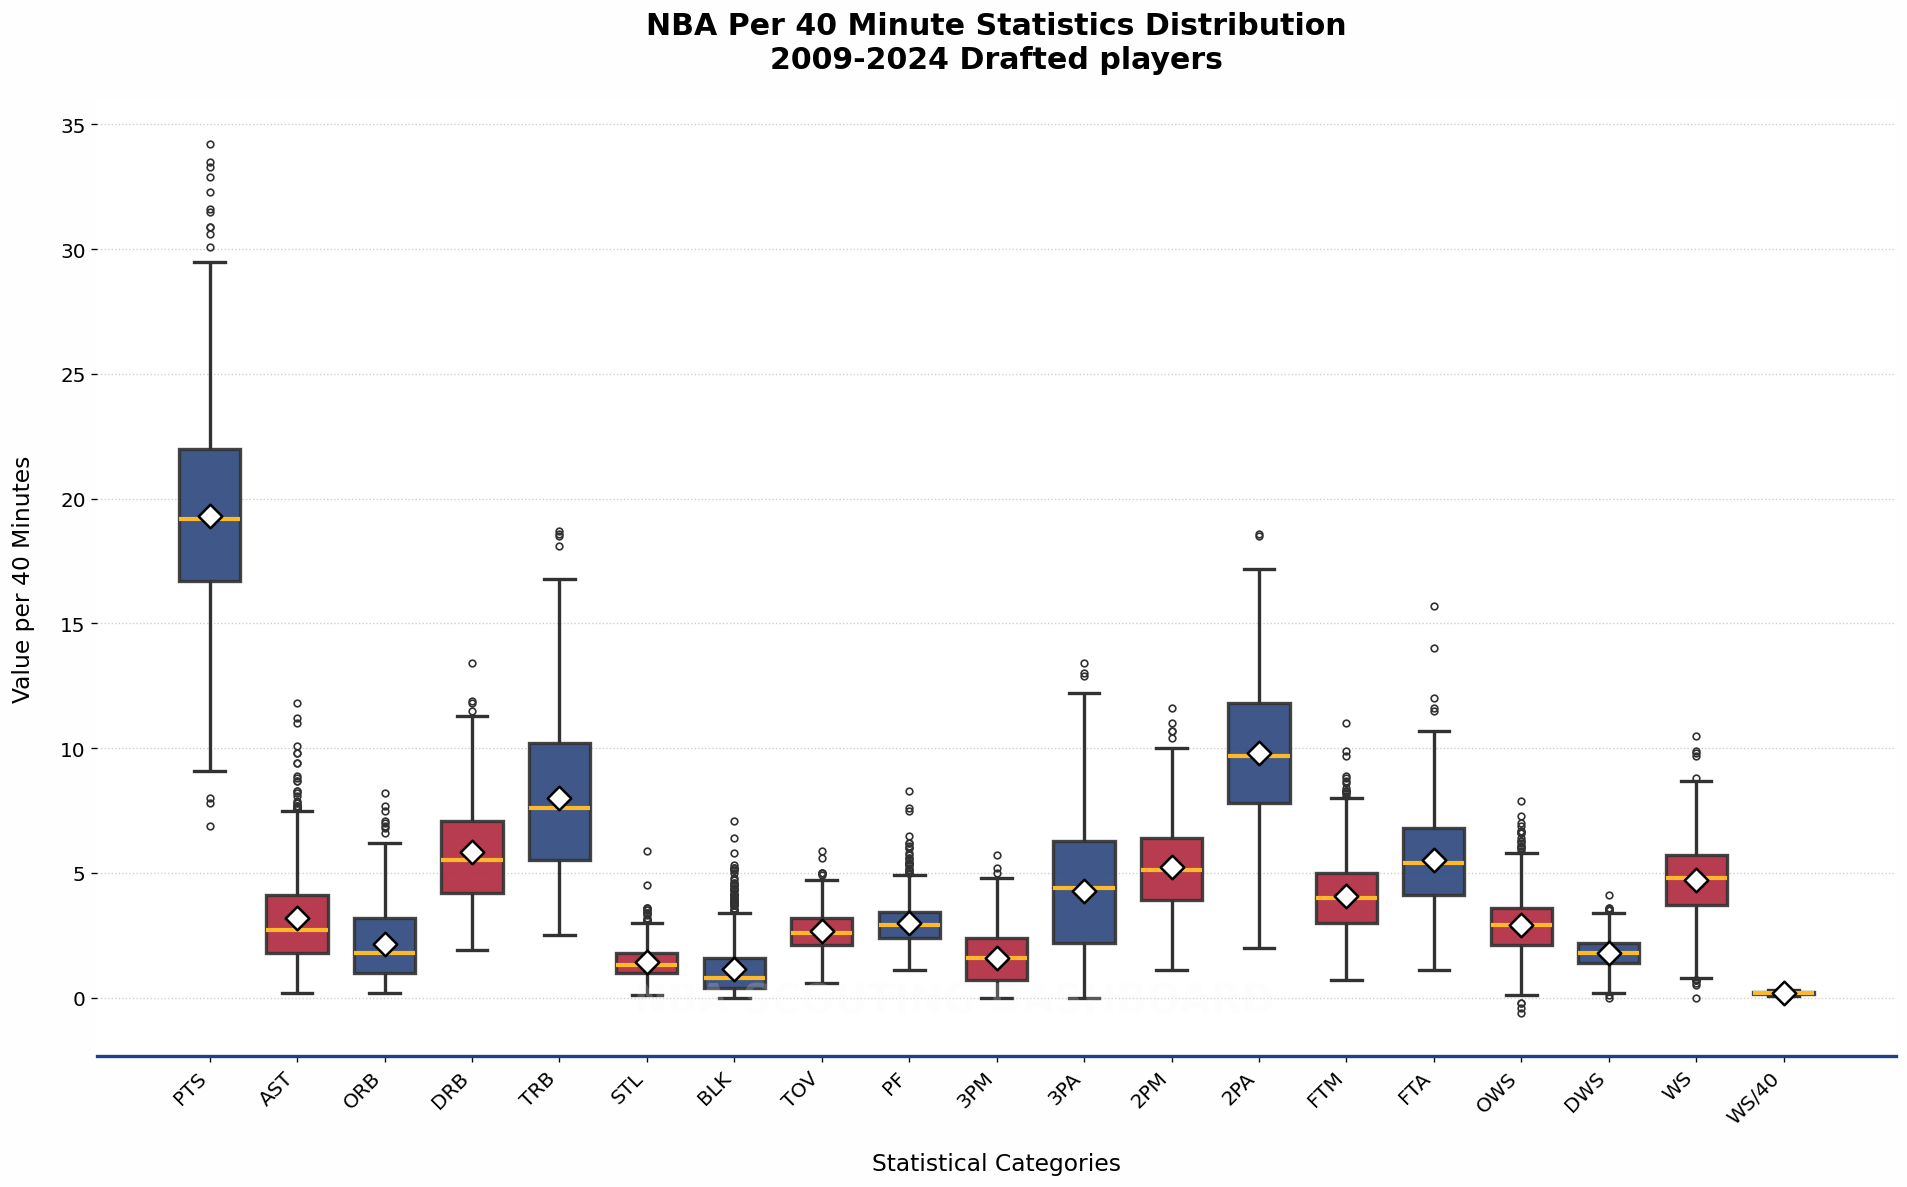

In [141]:
plt.figure(figsize=(16, 10), facecolor='#FEFEFE', dpi=120)

# NBA color palette
primary_color = '#1D428A'  # Warriors blue
secondary_color = '#C8102E'  # Bulls red
tertiary_color = '#FDB927'  # Lakers gold

# Create custom palette - alternate colors for better differentiation
custom_palette = [primary_color if i%2==0 else secondary_color for i in range(len(per40_cols))]

# Create the boxplot
ax = sns.boxplot(data=df[per40_cols], 
                palette=custom_palette,
                width=0.7,
                linewidth=2,
                fliersize=4,
                boxprops=dict(alpha=0.9),
                medianprops=dict(color=tertiary_color, linewidth=2.5))

# Custom x-tick labels with abbreviations
stat_labels = ['PTS', 'AST', 'ORB', 'DRB', 'TRB', 'STL', 'BLK', 
               'TOV', 'PF', '3PM', '3PA', '2PM', '2PA', 'FTM', 'FTA', 
               'OWS', 'DWS', 'WS', 'WS/40']

# Add mean markers
for i, col in enumerate(per40_cols):
    mean_val = df[col].mean()
    ax.scatter(i, mean_val, color='white', edgecolor='black', 
               s=100, zorder=3, linewidth=1.5, marker='D')

# Styling enhancements
plt.title('NBA Per 40 Minute Statistics Distribution\n2009-2024 Drafted players', 
          fontsize=18, pad=20, color='black', fontweight='bold')
plt.xlabel('Statistical Categories', fontsize=14, labelpad=15)
plt.ylabel('Value per 40 Minutes', fontsize=14, labelpad=15)
plt.xticks(range(len(per40_cols)), stat_labels, 
           rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Add grid and adjust spines
ax.set_axisbelow(True)
ax.grid(axis='y', linestyle=':', alpha=0.4, color='grey')
sns.despine(top=True, right=True, left=True)
ax.spines['bottom'].set_color(primary_color)
ax.spines['bottom'].set_linewidth(2)

# Add NBA-style watermark
plt.figtext(0.5, 0.15, "NBA SCOUTING DASHBOARD", 
            ha="center", fontsize=24, 
            color='#F5F5F5', alpha=0.2, fontweight='bold')


plt.tight_layout()
plt.show()

## Class distribution

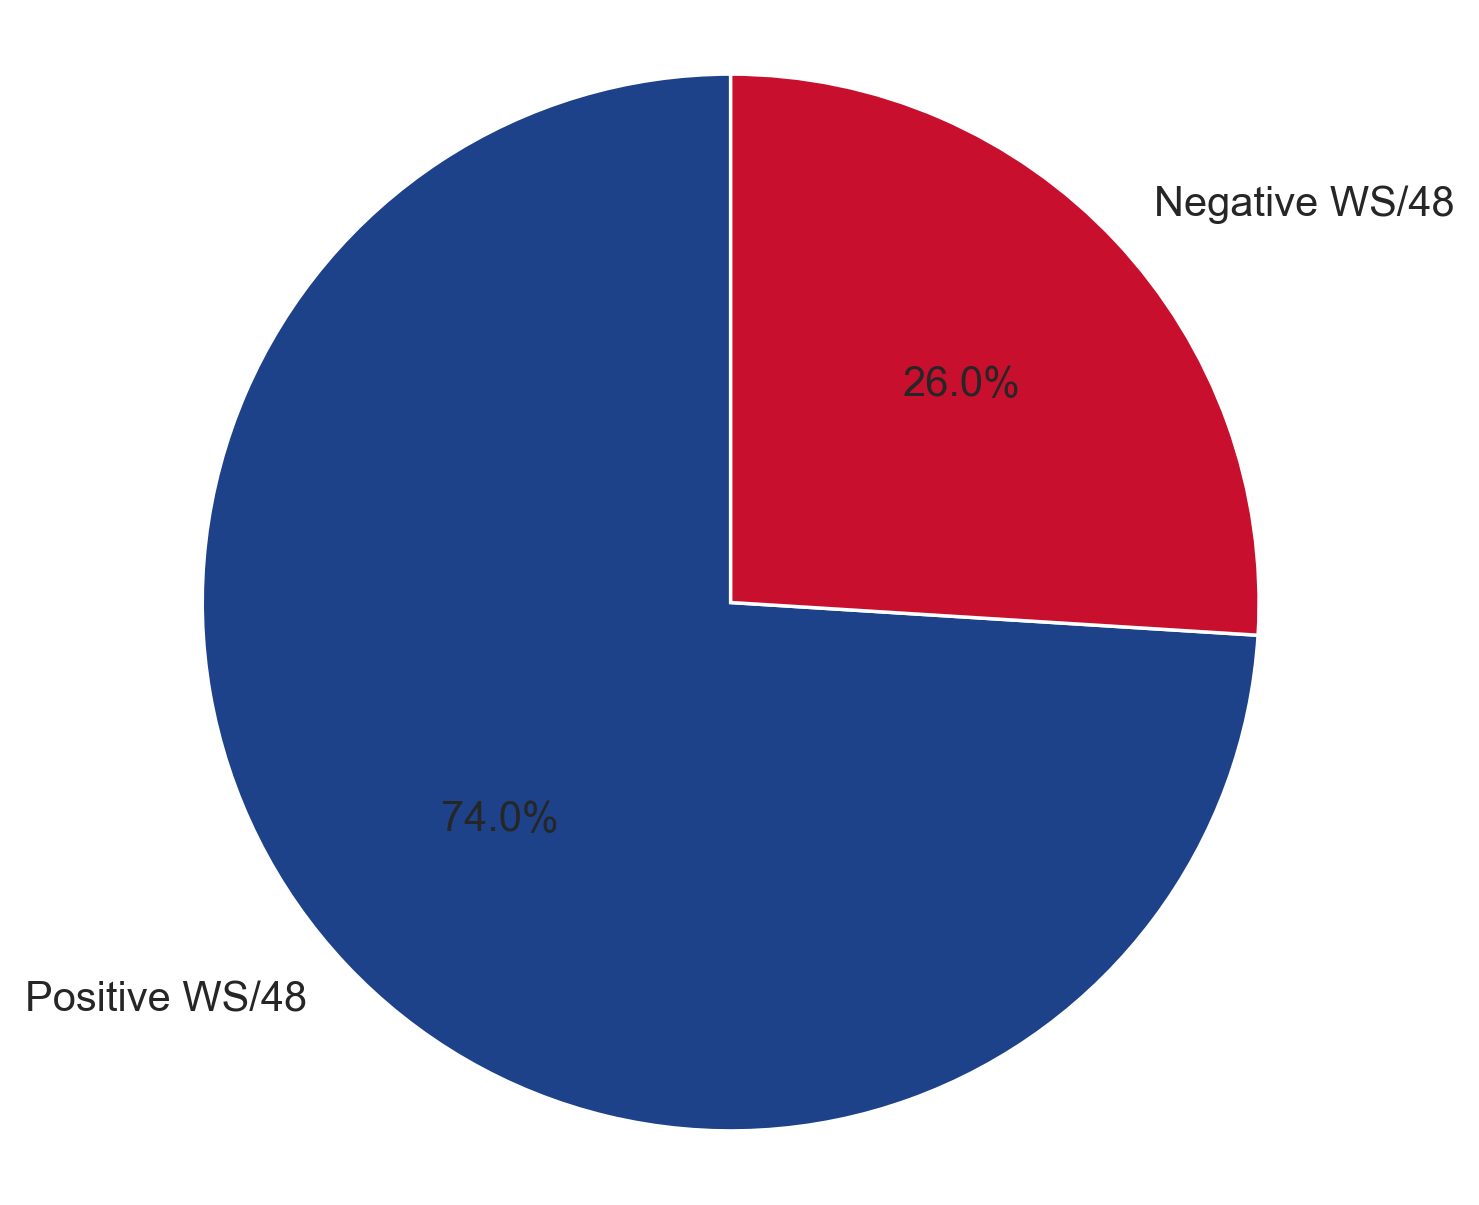

In [339]:
working_df['med_tresh']
# Compter le nombre d'occurrences de chaque classe dans 'med_tresh'
class_counts = working_df['med_tresh'].value_counts()

# Création du pie chart
plt.figure(figsize=(6, 6), dpi=250)
plt.pie(class_counts, labels=['Positive WS/48', 'Negative WS/48'], autopct='%1.1f%%', startangle=90,
        colors=[nba_palette[0], nba_palette[2]])
plt.axis('equal')  # Pour un cercle parfait
plt.show()

## Next

# Modelling

## TF-IDF Pipeline

In [66]:
test_idf = pd.read_excel(r"C:\Users\Utilisateur\Desktop\Master ULB\Mémoire\Thesis - Code\tf_idf_df.xlsx")

In [67]:
features = [key for key in test_idf.columns if 'feature' in key]
filtered_list = [key for key in features if 'context' not in key]

In [68]:
#0. Pipeline configuration
config = {
    'test_size': 0.2,
    'n_folds': 5,
    'n_iter' : 200, 
    'scoring': 'roc_auc',
    'features_max': 100,
    'features_sets' : {
        'With': features,
        'Without' : filtered_list
    }
}

dico_features_tfidf = {}

#1 y creation 
i = 1
#test_idf['med_tresh'] = (test_idf[f'WS/48-{i}_target'] > 0).astype(int)
y = test_idf['med_tresh']

#2 X Creation
X_raw = test_idf[features] #Full dataset with every features


## Base pipeline
base_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('resampler', SMOTETomek(random_state=143)),
    ('classifier', None)
])

#3. Classification model definition
classifiers = {
    'xgboost': XGBClassifier(random_state=48, 
                             eval_metric='auc'),
    'logistic_regression': LogisticRegression(random_state=42, 
                                              penalty='elasticnet',
                                              solver='saga'),
    'random_forest': RandomForestClassifier(random_state=42, 
                                            max_samples=0.7),
    'svm': SVC(random_state=42, 
               probability=True)
}

#4. Parameters search space
search_spaces = {
    'xgboost': {
        'classifier__learning_rate': Real(0.01, 0.2, prior='log-uniform'),
        'classifier__max_depth': Integer(2, 4),
        'classifier__n_estimators': Integer(100, 500),
        'classifier__subsample': Real(0.6, 1.0, 'uniform'),
        'classifier__colsample_bytree': Real(0.6, 1.0, 'uniform'),
        'classifier__gamma': Real(0, 1),
        #'feature_selection__max_features': Integer(1, X.shape[1]),
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        #'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    },
    'logistic_regression': {
        'classifier__C': Real(0.01, 10.0, prior='log-uniform'),
        #'feature_selection__max_features': Integer(1, X.shape[1]),
        'classifier__l1_ratio': Real(0.3, 0.7, 'uniform'),
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        #'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    },
    'random_forest': {
        'classifier__n_estimators': Integer(100, 500),
        'classifier__max_depth': Integer(2, 4),
        'classifier__min_samples_split': Integer(5, 20),
        'classifier__max_features': Categorical(['sqrt', 0.5]),
        #'feature_selection__max_features': Integer(1, X.shape[1]),
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        #'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    },
    'svm': {
        'classifier__C': Real(0.5, 50.0, prior='log-uniform'),
        'classifier__gamma': Categorical(['scale', 'auto'] + list(np.logspace(-3, -1, 5))),
        'classifier__kernel': Categorical(['rbf', 'linear']),
        #'feature_selection__max_features': Integer(1, X.shape[1]), 
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        #'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    }
}

final_results = []
for features_set_name, context in config['features_sets'].items():
    X = X_raw[context]
    #X = X_raw[dico_features['Without']]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=config['test_size'],
        stratify=y,
        random_state=42
    )
    X_train_selected, X_test_selected, features_selected, best_max_features = select_features(
        X_train, X_test, y_train,
        max_features_range=(25, 50),
        n_iter=config['n_iter'])

    dico_features_tfidf[features_set_name] = features_selected

    #df_results = optimized_training(
     #   X_train_selected, X_test_selected, 
      #  y_train, y_test,
       # classifiers, config, 
        #'randomforest', search_spaces
    #)

    #final_results.append(df_results)

#final_df = pd.concat(final_results)
#final_df

Optimisation de max_features avec randomforest...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fittin

c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(49)] before, using random point [np.int64(45)]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(49)] before, using random point [np.int64(45)]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits


...

Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(44)] before, using random point [np.int64(37)]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(44)] before, using random point [np.int64(39)]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits
max_features optimal: 33
Nombre de caractéristiques sélectionnées: 19
Caractéristiques sélectionnées: ['Weight_features', 'per_40_FG%_features', 'per_40_3P%_features', 'per_40_2P%_features', 'per_40_FT%_features', 'per_40_ORB_features', 'per_40_TRB_features', 'per_40_STL_features', 'per_40_TOV_features', 'advanced_PER_features', 'advanced_3PAr_features', 'advanced_FTr_features', 'advanced_ORB%_features', 'advanced_AST%_features', 'advanced_STL%_features', 'advanced_BLK%_features', 'advanced_WS/40_features', 'advanced_OBPM_features', 'advanced_BPM_features']


In [95]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
##Contingency Table of the best model 
#1 y creation 
y = test_idf['med_tresh']

#2 X Creation
X = test_idf[dico_features_tfidf['With']] #Full dataset with every features

X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=config['test_size'],
        stratify=y,
        random_state=42
    )

## Base pipeline
base_pipeline = ImbPipeline([
            ('scaler', StandardScaler()),
            ('resampler', SMOTETomek(sampling_strategy=0.7, random_state=143)),
            ('classifier', XGBClassifier(
                learning_rate=0.01,
                max_depth=10,
                n_estimators=298,
                subsample=0.6804196802009144,
                colsample_bytree=0.6,
                gamma=0.0,
                random_state=48
            ))
        ])

        #X_train, X_test, y_train, y_test = train_test_split(
        #    X, y, 
        #    test_size=config['test_size'],
        #    stratify=y,
        #    random_state=42
        #)
        #X_train_selected, X_test_selected, final_features, best_max_features = select_features(
        #    X_train, X_test, y_train,
        #    max_features_range=(25, 50),
        #    n_iter=config['n_iter'])

base_pipeline.fit(X_train, y_train)
train_pred = base_pipeline.predict(X_train)
test_pred = base_pipeline.predict(X_test)
train_proba = base_pipeline.predict_proba(X_train)[:, 1]
test_proba = base_pipeline.predict_proba(X_test)[:, 1]
y_pred = base_pipeline.predict(X_test)
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)
auc = roc_auc_score(y_test, test_proba)
print(f'test acc: {test_acc}, train acc: {train_acc}, f1: {f1}, auc: {auc}')


test acc: 0.7704918032786885, train acc: 0.9917695473251029, f1: 0.8581081081081081, auc: 0.828858024691358


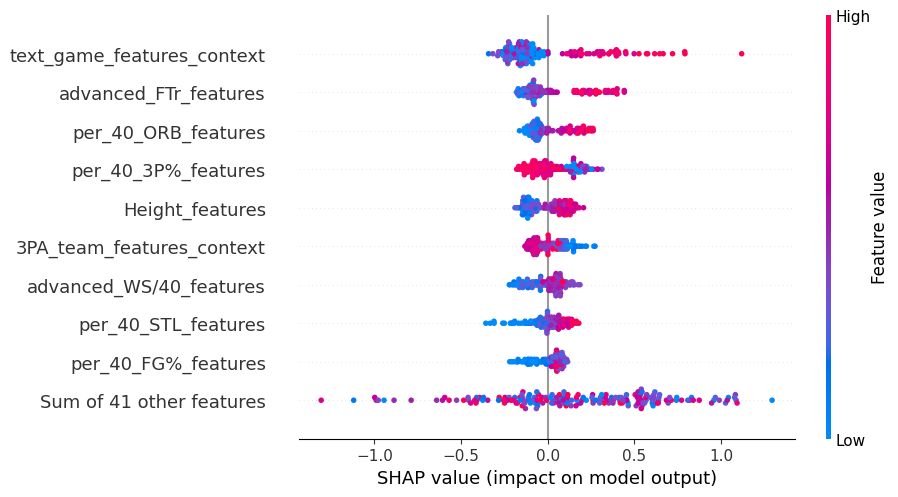

In [96]:
import shap
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

from imblearn.combine import SMOTETomek
sm = SMOTETomek(sampling_strategy = 0.7, random_state=143)
X_resampled, y_resampled = sm.fit_resample(X_train_scaled, y_train)

model = XGBClassifier(learning_rate=0.01,
                        max_depth=7,
                        n_estimators=298,
                        subsample=0.6804196802009144,
                        colsample_bytree=0.6,
                        gamma=0.0,
                        random_state=48)
model.fit(X_resampled, y_resampled)

# =======================
# 6. SHAP sur les données de test (non résamplées)
# =======================
# Important : on utilise X_test_scaled pour une vraie interprétation
explainer = shap.Explainer(model, X_resampled)
shap_values = explainer(X_test_scaled_df)

# =======================
# 7. Beeswarm plot
# =======================
# shap.plots.beeswarm accepte un DataFrame ou numpy array
shap.plots.beeswarm(shap_values, max_display=10)  # Tu peux augmenter ou réduire max_display

## Pipeline

In [5]:
working_df = pd.read_excel(r'C:\Users\Utilisateur\Desktop\Master ULB\Mémoire\Thesis - Code\df_for_final.xlsx')

In [59]:
test_idf = pd.read_excel(r'C:\Users\Utilisateur\Desktop\Master ULB\Mémoire\Thesis - Code\tfidf_df.xlsx')

In [9]:
def select_features(X_train, X_test, y_train, 
                    selector='randomforest', max_features_range=(1, 50), 
                    n_iter=10):
    """
    Sélectionne un sous-ensemble optimal de caractéristiques avec SelectFromModel en optimisant max_features.
    
    Parameters:
    -----------
    X_train : pd.DataFrame
        Données d'entraînement.
    X_test : pd.DataFrame
        Données de test.
    y_train : np.array
        Cibles d'entraînement.
    selector : str
        Nom du sélecteur (par exemple, 'randomforest').
    max_features_range : tuple
        Plage pour max_features (par exemple, (1, X.shape[1])).
    n_iter : int
        Nombre d'itérations pour BayesSearchCV.
        
    Returns:
    --------
    X_train_selected : np.array
        Données d'entraînement avec caractéristiques sélectionnées.
    X_test_selected : np.array
        Données de test avec caractéristiques sélectionnées.
    selected_features : list
        Liste des noms des caractéristiques sélectionnées.
    best_max_features : int
        Valeur optimale de max_features.
    """
    print(f"Optimisation de max_features avec {selector}...")
    
    # Pipeline pour la sélection
    pipeline = ImbPipeline([
        ('scaler', StandardScaler()),
        ('resampler', SMOTETomek(random_state=42, sampling_strategy=0.5)),
        ('selector', SelectFromModel(
            estimator=RandomForestClassifier(random_state=42, class_weight='balanced', 
                                         )
        )),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000, 
                                          class_weight='balanced'))  # Classifieur de référence
    ])
    
    # Espace de recherche pour max_features
    search_spaces = {
        'selector__max_features': Integer(max_features_range[0], min(max_features_range[1], X_train.shape[1]))
    }
    
    # Optimisation avec BayesSearchCV
    search = BayesSearchCV(
        estimator=pipeline,
        search_spaces=search_spaces,
        n_iter=n_iter,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='roc_auc',
        n_jobs=-1,
        verbose=2,
        random_state=42
    )
    
    search.fit(X_train, y_train)
    best_max_features = search.best_params_['selector__max_features']
    
    # Ajustement final avec max_features optimal
    feature_selector = ImbPipeline([
        ('scaler', StandardScaler()),
        ('resampler', SMOTETomek(random_state=42, sampling_strategy=0.5)),
        ('selector', SelectFromModel(
            estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
            max_features=best_max_features
        ))
    ])
    
    feature_selector.fit(X_train, y_train)
    X_train_selected = feature_selector.transform(X_train)
    X_test_selected = feature_selector.transform(X_test)
    
    # Récupération des caractéristiques sélectionnées
    selected_mask = feature_selector.named_steps['selector'].get_support()
    selected_features = X_train.columns[selected_mask].tolist()
    
    print(f"max_features optimal: {best_max_features}")
    print(f"Nombre de caractéristiques sélectionnées: {len(selected_features)}")
    print(f"Caractéristiques sélectionnées: {selected_features}")
    

    
    return X_train_selected, X_test_selected, selected_features, best_max_features

In [40]:
def optimized_training(X_train, X_test, 
                       y_train, y_test,
                       classifiers, config,
                       selector, search_spaces
                    ):
    
    results = []
    for model_name in classifiers:
        pipeline = base_pipeline.set_params(classifier=classifiers[model_name])

        search = BayesSearchCV(
            estimator=pipeline,
            search_spaces=search_spaces[model_name],
            n_iter=config['n_iter'],
            cv=StratifiedKFold(config['n_folds']),
            scoring=config['scoring'],
            n_jobs=-1,
            verbose=2,
            random_state=42
        )

        start_time = time()
        search.fit(X_train, y_train)
        training_time = (time() - start_time)/60  # en minutes
        
        #Entrainement avec les meilleurs hyperparamètres sur le dataset complet
        best_params = search.best_params_

        # Réentraîner avec les meilleurs hyperparamètres sur l'ensemble d'entraînement
        best_pipeline = base_pipeline.set_params(classifier=classifiers[model_name])
        best_pipeline.set_params(**best_params)
        best_pipeline.fit(X_train, y_train)  # ou X et y si tu veux tout utiliser

        # Sauvegarde du modèle réentraîné
        joblib.dump(best_pipeline, f"with_cond_best_model_retrained_{features_set_name}_{model_name.replace(' ', '_')}_{selector}.pkl")

        # Prédictions
        train_pred = best_pipeline.predict(X_train)
        test_pred = best_pipeline.predict(X_test)
        train_proba = best_pipeline.predict_proba(X_train)[:, 1]
        test_proba = best_pipeline.predict_proba(X_test)[:, 1]

        # Stockage des résultats
        results.append({
            'Features Set': features_set_name,
            'Model': model_name,
            'Train Accuracy': accuracy_score(y_train, train_pred),
            'Test Accuracy': accuracy_score(y_test, test_pred),
            'F1': f1_score(y_test, test_pred),
            'Best AUC': roc_auc_score(y_test, test_proba),
            'Training Time (min)': round(training_time, 1),
            'Nb features' : X_train.shape[1],
            'Best Params': best_params
        })
    
    return pd.DataFrame(results)

In [6]:
features = [key for key in working_df.columns if 'feature' in key]
filtered_list = [key for key in features if 'context' not in key]

### With the missing scouting reports

In [51]:
#0. Pipeline configuration
config = {
    'test_size': 0.2,
    'n_folds': 5,
    'n_iter' : 200, 
    'scoring': 'roc_auc',
    'features_max': 100,
    'features_sets' : {
        #'With': features,
        'Without' : filtered_list
    }
}

#dico_features = {}

#1 y creation 
i = 1
#df['med_tresh'] = (df[f'WS/48-{i}_target'] > 0).astype(int)
y = working_df['med_tresh']

#2 X Creation
X_raw = working_df[features] #Full dataset with every features


## Base pipeline
base_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('resampler', SMOTETomek(random_state=143)),
    ('classifier', None)
])

#3. Classification model definition
classifiers = {
    'xgboost': XGBClassifier(random_state=48, 
                             eval_metric='auc'),
    'logistic_regression': LogisticRegression(random_state=42, 
                                              penalty='elasticnet',
                                              solver='saga'),
    'random_forest': RandomForestClassifier(random_state=42, 
                                            max_samples=0.7),
    'svm': SVC(random_state=42, 
               probability=True)
}

#4. Parameters search space
search_spaces = {
    'xgboost': {
        'classifier__learning_rate': Real(0.01, 0.2, prior='log-uniform'),
        'classifier__max_depth': Integer(2, 4),
        'classifier__n_estimators': Integer(100, 500),
        'classifier__subsample': Real(0.6, 1.0, 'uniform'),
        'classifier__colsample_bytree': Real(0.6, 1.0, 'uniform'),
        'classifier__gamma': Real(0, 1),
        #'feature_selection__max_features': Integer(1, X.shape[1]),
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        #'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    },
    'logistic_regression': {
        'classifier__C': Real(0.01, 10.0, prior='log-uniform'),
        #'feature_selection__max_features': Integer(1, X.shape[1]),
        'classifier__l1_ratio': Real(0.3, 0.7, 'uniform'),
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        #'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    },
    'random_forest': {
        'classifier__n_estimators': Integer(100, 500),
        'classifier__max_depth': Integer(2, 4),
        'classifier__min_samples_split': Integer(5, 20),
        'classifier__max_features': Categorical(['sqrt', 0.5]),
        #'feature_selection__max_features': Integer(1, X.shape[1]),
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        #'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    },
    'svm': {
        'classifier__C': Real(0.5, 50.0, prior='log-uniform'),
        'classifier__gamma': Categorical(['scale', 'auto'] + list(np.logspace(-3, -1, 5))),
        'classifier__kernel': Categorical(['rbf', 'linear']),
        #'feature_selection__max_features': Integer(1, X.shape[1]), 
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        #'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    }
}

final_results = []
for features_set_name, context in config['features_sets'].items():
    #X = X_raw[context]
    X = X_raw[dico_features['Without']]
    X_train_selected, X_test_selected, y_train, y_test = train_test_split(
        X, y, 
        test_size=config['test_size'],
        stratify=y,
        random_state=42
    )
    #X_train_selected, X_test_selected, features_selected, best_max_features = select_features(
     #   X_train, X_test, y_train,
      #  max_features_range=(25, 50),
       # n_iter=config['n_iter'])

    #dico_features[features_set_name] = features_selected

    df_results = optimized_training(
        X_train_selected, X_test_selected, 
        y_train, y_test,
        classifiers, config, 
        'randomforest', search_spaces
    )

    final_results.append(df_results)

final_df = pd.concat(final_results)
final_df

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

...

c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.5, np.str_('auto'), np.str_('rbf'), 0.7] before, using random point [10.132564915160085, np.float64(0.001), 'rbf', 0.5233536742089421]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.5, np.str_('auto'), np.str_('rbf'), 0.7] before, using random point [0.7424889532973095, np.float64(0.0031622776601683794), 'linear', 0.6307233577444057]
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

,Features Set,Model,Train Accuracy,Test Accuracy,F1,Best AUC,Training Time (min),Nb features,Best Params
0,Without,xgboost,0.861454,0.743169,0.843854,0.762963,20.7,19,"{'classifier__colsample_bytree': 1.0, 'classif..."
1,Without,logistic_regression,0.740741,0.710383,0.817869,0.734722,8.3,19,"{'classifier__C': 0.2438777777137868, 'classif..."
2,Without,random_forest,0.790123,0.759563,0.855263,0.785340,12.6,19,"{'classifier__max_depth': 4, 'classifier__max_..."
3,Without,svm,0.714678,0.704918,0.801471,0.757948,22.0,19,"{'classifier__C': 7.120101845616815, 'classifi..."


In [111]:
final_df #Without context

,Features Set,Model,Train Accuracy,Test Accuracy,F1,Best AUC,Training Time (min),Nb features,Best Params
0,Without,xgboost,0.858711,0.765027,0.852234,0.738735,50.9,19,{'classifier__colsample_bytree': 0.67260661681...
1,Without,logistic_regression,0.709191,0.688525,0.786517,0.723611,12.0,19,"{'classifier__C': 7.352481813242629, 'classifi..."
2,Without,random_forest,0.842250,0.754098,0.850498,0.714969,26.7,19,"{'classifier__max_depth': 6, 'classifier__max_..."
3,Without,svm,0.733882,0.737705,0.835616,0.751389,26.3,19,"{'classifier__C': 43.54723567932927, 'classifi..."


In [131]:
final_df #With context

,Features Set,Model,Train Accuracy,Test Accuracy,F1,Best AUC,Training Time (min),Nb features,Best Params
0,With,xgboost,0.890261,0.781421,0.865772,0.802778,41.1,50,{'classifier__colsample_bytree': 0.87362620003...
1,With,logistic_regression,0.746228,0.775956,0.853047,0.766512,32.2,50,"{'classifier__C': 0.48076938145952414, 'classi..."
2,With,random_forest,0.906722,0.775956,0.856140,0.767901,78.7,50,"{'classifier__max_depth': 6, 'classifier__max_..."
3,With,svm,0.703704,0.683060,0.780303,0.708951,102.1,50,"{'classifier__C': 48.82021518551036, 'classifi..."


In [ ]:
final_df #full from 13-05

In [52]:
for i in final_df['Best Params']:
    print(i)

OrderedDict({'classifier__colsample_bytree': 1.0, 'classifier__gamma': 1.0, 'classifier__learning_rate': 0.026942048775745225, 'classifier__max_depth': 4, 'classifier__n_estimators': 100, 'classifier__subsample': 0.6, 'resampler__sampling_strategy': 0.5})
OrderedDict({'classifier__C': 0.2438777777137868, 'classifier__l1_ratio': 0.5968269116101967, 'resampler__sampling_strategy': 0.5459460142341684})
OrderedDict({'classifier__max_depth': 4, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 15, 'classifier__n_estimators': 140, 'resampler__sampling_strategy': 0.5})
OrderedDict({'classifier__C': 7.120101845616815, 'classifier__gamma': 0.001, 'classifier__kernel': 'rbf', 'resampler__sampling_strategy': 0.7})


<Figure size 1000x100 with 0 Axes>

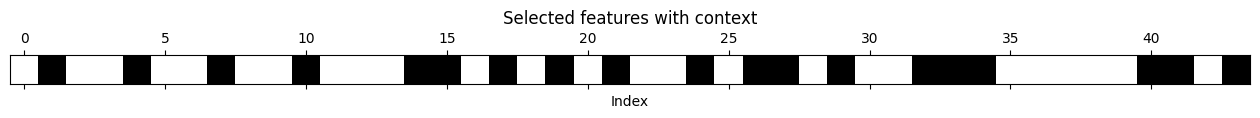

In [49]:
all_features = list(working_df[filtered_list].columns)

# OU : tu crées manuellement le masque à partir de ta liste de features sélectionnées
mask = np.array([feature in dico_features['Without'] for feature in all_features])

# Affichage en image : une ligne horizontale de pixels noirs (True) ou blancs (False)
plt.figure(figsize=(10, 1))
plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel("Index")
plt.yticks([])
plt.title("Selected features with context")
plt.show()

# Results evaluation

In [167]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
##Contingency Table of the best model 
#1 y creation 
y = working_df['med_tresh']

#2 X Creation
X = working_df[features] #Full dataset with every features


## Base pipeline
for i in range(0, 201):
    base_pipeline = ImbPipeline([
            ('scaler', StandardScaler()),
            ('resampler', SMOTETomek(sampling_strategy=0.7, random_state=i)),
            ('classifier', XGBClassifier(
                learning_rate=0.01,
                max_depth=7,
                n_estimators=298,
                subsample=0.6804196802009144,
                colsample_bytree=0.6,
                gamma=0.0,
                random_state=48
            ))
        ])

        #X_train, X_test, y_train, y_test = train_test_split(
        #    X, y, 
        #    test_size=config['test_size'],
        #    stratify=y,
        #    random_state=42
        #)
        #X_train_selected, X_test_selected, final_features, best_max_features = select_features(
        #    X_train, X_test, y_train,
        #    max_features_range=(25, 50),
        #    n_iter=config['n_iter'])

    base_pipeline.fit(X_train_selected, y_train)
    train_pred = base_pipeline.predict(X_train_selected)
    test_pred = base_pipeline.predict(X_test_selected)
    train_proba = base_pipeline.predict_proba(X_train_selected)[:, 1]
    test_proba = base_pipeline.predict_proba(X_test_selected)[:, 1]
    y_pred = base_pipeline.predict(X_test_selected)
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    f1 = f1_score(y_test, test_pred)
    auc = roc_auc_score(y_test, test_proba)
    auc_dic[f'random_state_{i}'] = auc
for i, j in auc_dic.items():
    print(i, j)

random_state_0 0.7859567901234568
random_state_1 0.796141975308642
random_state_2 0.7671296296296296
random_state_3 0.8098765432098765
random_state_4 0.762037037037037
random_state_5 0.7912037037037037
random_state_6 0.775
random_state_7 0.7529320987654321
random_state_8 0.7679012345679013
random_state_9 0.7694444444444445
random_state_10 0.7719135802469137
random_state_11 0.7645061728395062
random_state_12 0.7652777777777777
random_state_13 0.773611111111111
random_state_14 0.7887345679012344
random_state_15 0.7672839506172839
random_state_16 0.7748456790123456
random_state_17 0.7651234567901235
random_state_18 0.7703703703703704
random_state_19 0.7496913580246913
random_state_20 0.7737654320987655
random_state_21 0.8021604938271605
random_state_22 0.7868827160493826
random_state_23 0.7780864197530865
random_state_24 0.7691358024691358
random_state_25 0.7780864197530863
random_state_26 0.759104938271605
random_state_27 0.7782407407407408
random_state_28 0.8033950617283951
random_state

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
##Contingency Table of the best model 
#1 y creation 
y = working_df['med_tresh']

#2 X Creation
X = working_df[dico_features['With']] #Full dataset with every features

X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=config['test_size'],
        stratify=y,
        random_state=42
    )

## Base pipeline
base_pipeline = ImbPipeline([
            ('scaler', StandardScaler()),
            ('resampler', SMOTETomek(sampling_strategy=0.7, random_state=143)),
            ('classifier', XGBClassifier(
                learning_rate=0.01,
                max_depth=2,
                n_estimators=298,
                subsample=0.6804196802009144,
                colsample_bytree=0.6,
                gamma=0.0,
                random_state=48
            ))
        ])

        #X_train, X_test, y_train, y_test = train_test_split(
        #    X, y, 
        #    test_size=config['test_size'],
        #    stratify=y,
        #    random_state=42
        #)
        #X_train_selected, X_test_selected, final_features, best_max_features = select_features(
        #    X_train, X_test, y_train,
        #    max_features_range=(25, 50),
        #    n_iter=config['n_iter'])

base_pipeline.fit(X_train, y_train)
train_pred = base_pipeline.predict(X_train)
test_pred = base_pipeline.predict(X_test)
train_proba = base_pipeline.predict_proba(X_train)[:, 1]
test_proba = base_pipeline.predict_proba(X_test)[:, 1]
y_pred = base_pipeline.predict(X_test)
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)
auc = roc_auc_score(y_test, test_proba)
print(f'test acc: {test_acc}, train acc: {train_acc}, f1: {f1}, auc: {auc}')

test acc: 0.7759562841530054, train acc: 0.7722908093278463, f1: 0.856140350877193, auc: 0.8216049382716049


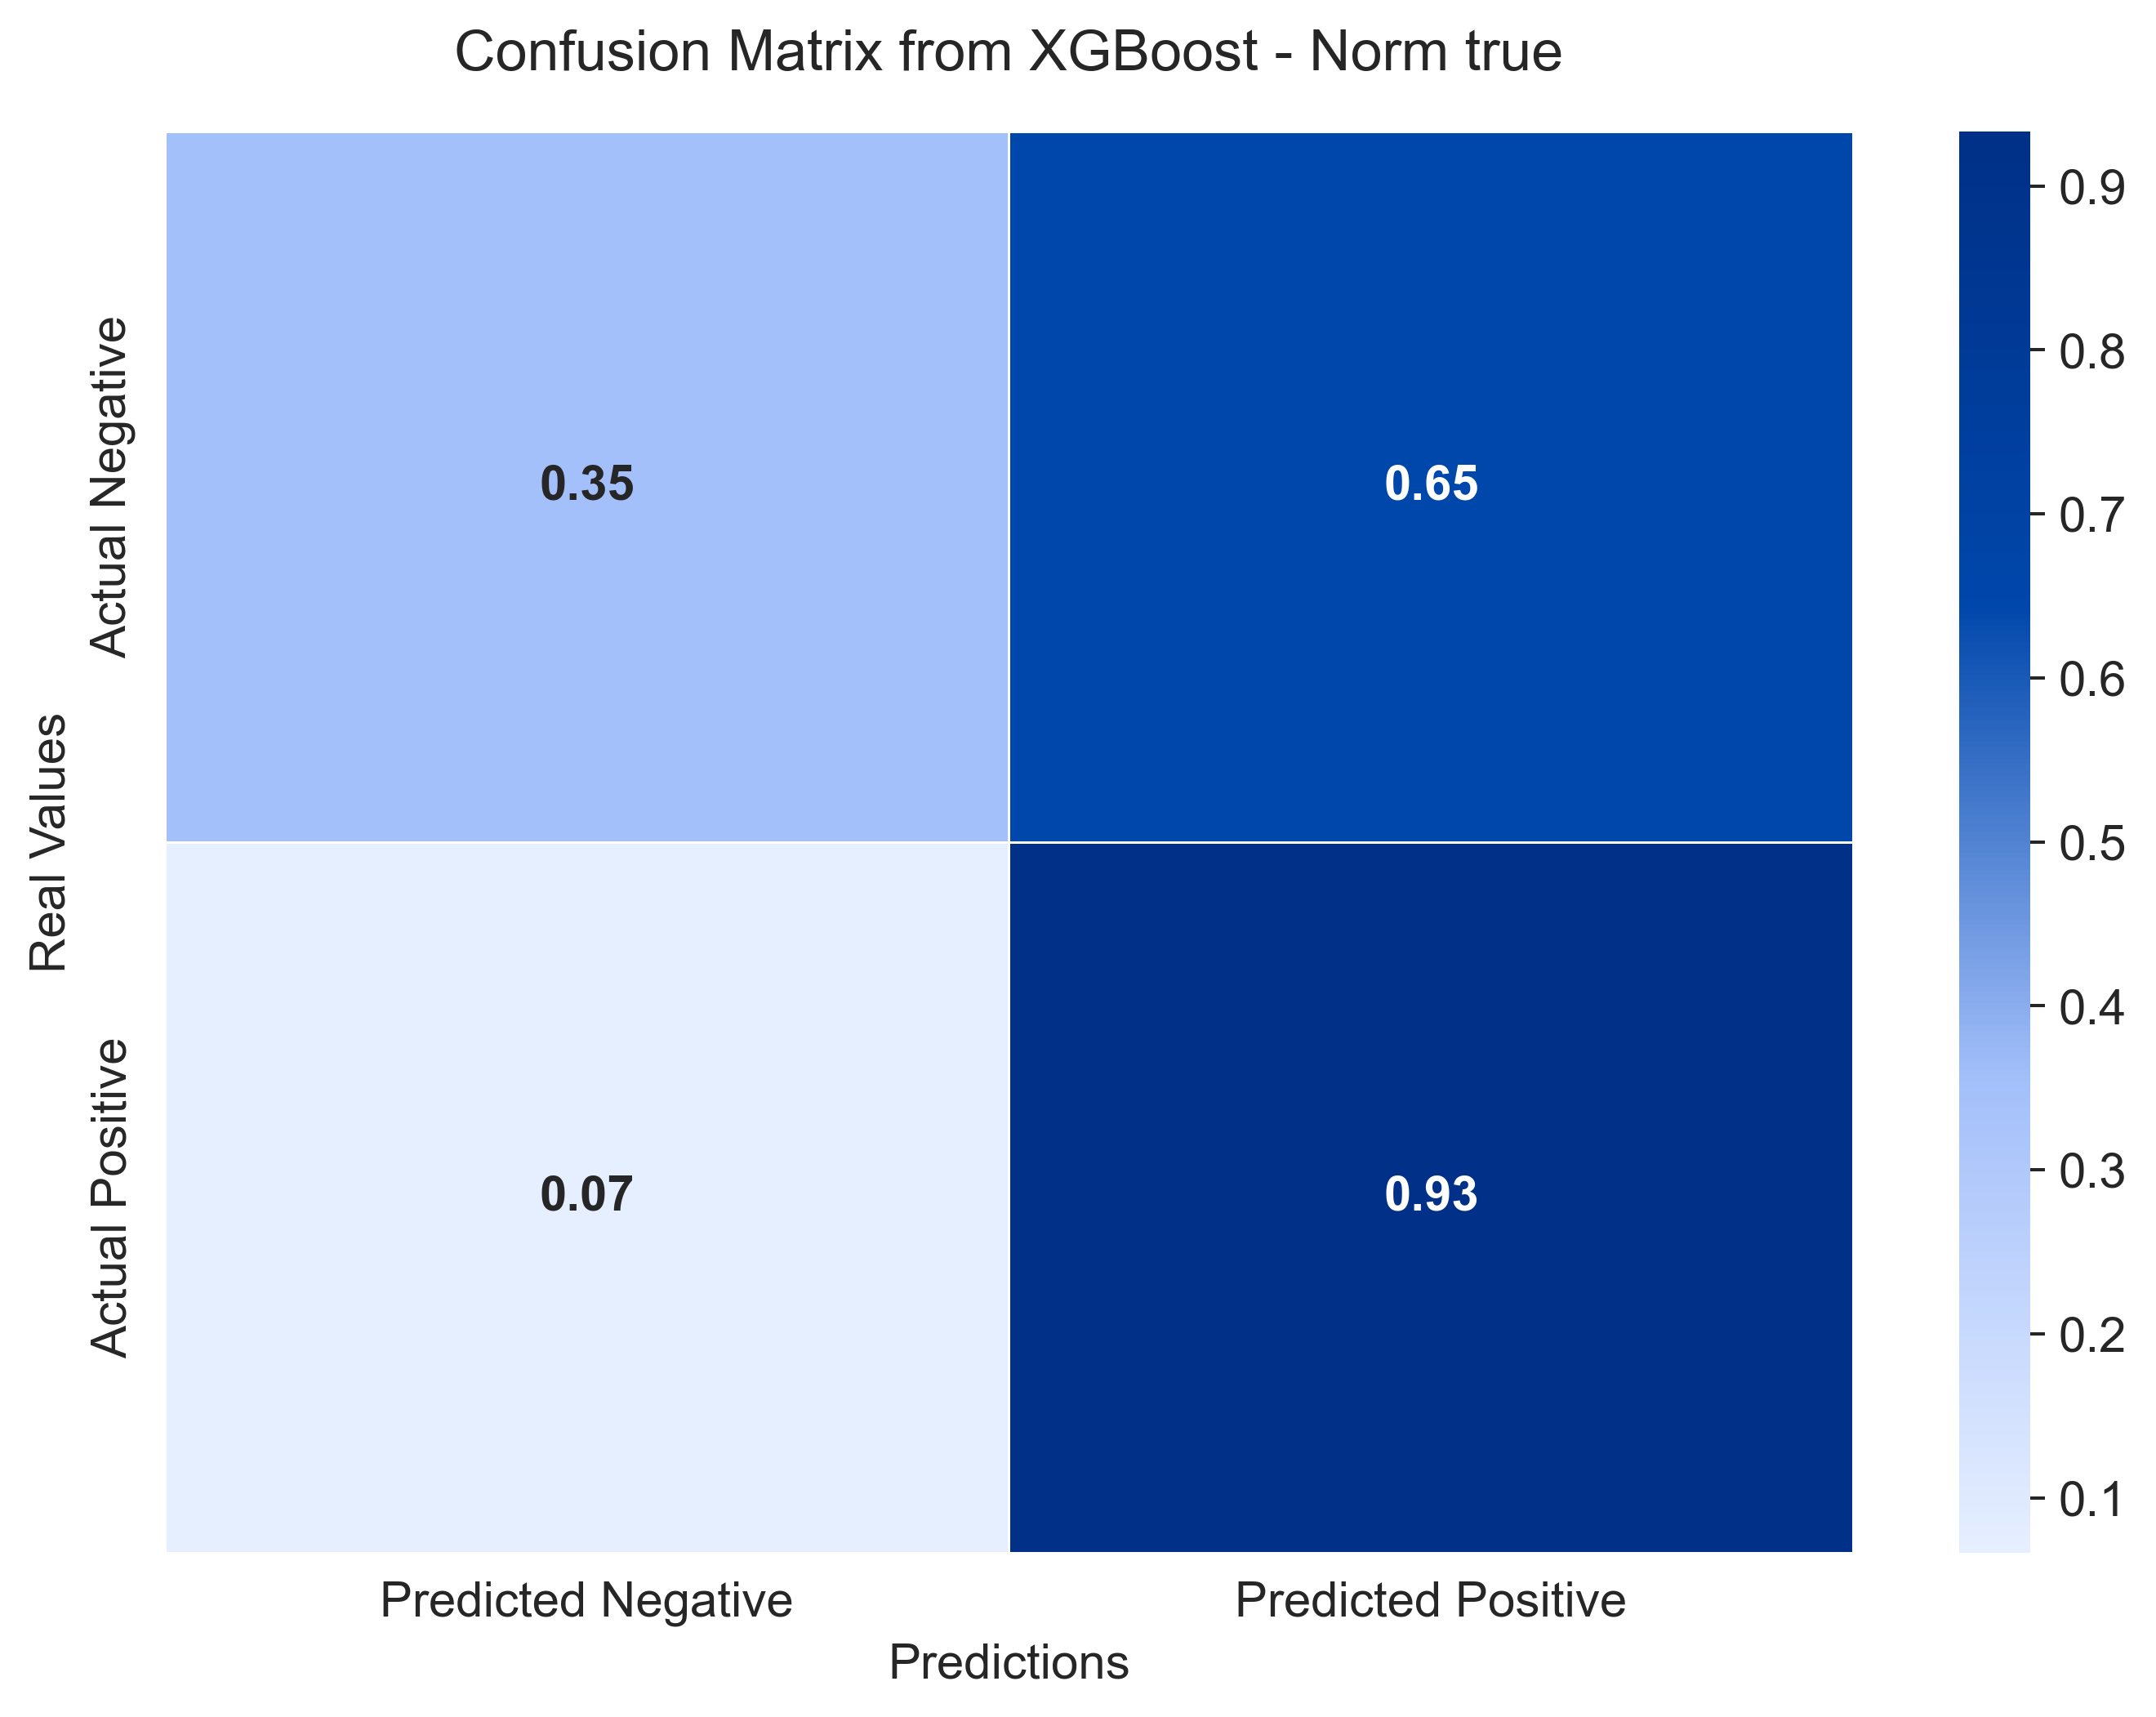

In [279]:
from matplotlib.colors import LinearSegmentedColormap

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')

# Optional: name the classes if you have them (e.g., 0: 'No', 1: 'Yes')
labels = ['Negative', 'Positive']

# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm, index=[f'Actual {label}' for label in labels],
                         columns=[f'Predicted {label}' for label in labels])

# Palette 1 : Philadelphia 76ers (bleu royal)
sixers_colors = ['#E6EFFF', '#A3BFFA', '#0047AB', '#003087']  # Très pâle, pâle, bleu moyen, bleu royal
sixers_cmap = LinearSegmentedColormap.from_list("Sixers", sixers_colors)

# Fonction pour afficher la matrice
def plot_confusion_matrix(cm_df, cmap, title):
    plt.figure(figsize=(8, 6), dpi=360)
    sns.heatmap(cm_df, annot=True, fmt='.2f', cmap=cmap, cbar=True,
                annot_kws={'size': 12, 'weight': 'bold'}, linewidths=0.5, 
                linecolor='white')
    plt.title(title, fontsize=14, pad=15)
    plt.xlabel('Predictions', fontsize=12)
    plt.ylabel('Real Values', fontsize=12)
    plt.tight_layout()
    plt.show()

# Afficher les deux versions
plot_confusion_matrix(cm_df, sixers_cmap, 'Confusion Matrix from XGBoost - Norm true')
#plot_confusion_matrix(cm_df, nba_vivid_cmap, 'Matrice de Confusion - Style Toronto Raptors')

### Without the missing scouting reports

In [277]:
working_df.set_index(df['player_id'], inplace=True)

In [138]:
#0. Pipeline configuration
config = {
    'test_size': 0.2,
    'n_folds': 5,
    'n_iter' : 200, 
    'scoring': 'roc_auc',
    'features_max': 100,
    'features_sets' : {
        'Without' : filtered_list,
        'With': features
    }
}

#1 y creation 
i = 1
#df['med_tresh'] = (df[f'WS/48-{i}_target'] > 0).astype(int)
y = working_df[working_df['flag_reports_features_context'] == 1]['med_tresh']

#2 X Creation
X_raw = working_df[working_df['flag_reports_features_context'] == 1][features] #Full dataset with every features


## Base pipeline
base_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('resampler', SMOTETomek(sampling_strategy=0.5)),
    ('classifier', None)
])

#3. Classification model definition
classifiers = {
    'xgboost': XGBClassifier(random_state=42, 
                             eval_metric='auc'),
    'logistic_regression': LogisticRegression(random_state=42, 
                                              penalty='elasticnet',
                                              solver='saga'),
    'random_forest': RandomForestClassifier(random_state=42, 
                                            max_samples=0.7),
    'svm': SVC(random_state=42, 
               probability=True)
}

#4. Parameters search space
search_spaces = {
    'xgboost': {
        'classifier__learning_rate': Real(0.01, 0.2, prior='log-uniform'),
        'classifier__max_depth': Integer(2, 7),
        'classifier__n_estimators': Integer(100, 500),
        'classifier__subsample': Real(0.6, 1.0, 'uniform'),
        'classifier__colsample_bytree': Real(0.6, 1.0, 'uniform'),
        'classifier__gamma': Real(0, 1),
        #'feature_selection__max_features': Integer(1, X.shape[1]),
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        #'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    },
    'logistic_regression': {
        'classifier__C': Real(0.01, 10.0, prior='log-uniform'),
        #'feature_selection__max_features': Integer(1, X.shape[1]),
        'classifier__l1_ratio': Real(0.3, 0.7, 'uniform'),
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        #'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    },
    'random_forest': {
        'classifier__n_estimators': Integer(100, 500),
        'classifier__max_depth': Integer(2, 6),
        'classifier__min_samples_split': Integer(5, 20),
        'classifier__max_features': Categorical(['sqrt', 0.5]),
        #'feature_selection__max_features': Integer(1, X.shape[1]),
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        #'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    },
    'svm': {
        'classifier__C': Real(0.5, 50.0, prior='log-uniform'),
        'classifier__gamma': Categorical(['scale', 'auto'] + list(np.logspace(-3, -1, 5))),
        'classifier__kernel': Categorical(['rbf', 'linear']),
        #'feature_selection__max_features': Integer(1, X.shape[1]), 
        #'feature_selection__estimator__l1_ratio': Real(0.1, 1.0),
        #'feature_selection__estimator__max_depth': Integer(2, 7),
        'resampler__sampling_strategy': Real(0.5, 0.7)
    }
}

final_results = []
for features_set_name, context in config['features_sets'].items():
    X = X_raw[context]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=config['test_size'],
        stratify=y,
        random_state=42
    )
    X_train_selected, X_test_selected, features_selected, best_max_features = select_features(
        X_train, X_test, y_train,
        max_features_range=(25, 50),
        n_iter=config['n_iter'])

    df_results = optimized_training(
        X_train_selected, X_test_selected, 
        y_train, y_test,
        classifiers, config, 
        'randomforest', search_spaces
    )

    final_results.append(df_results)

final_df_scout = pd.concat(final_results)
final_df_scout

Optimisation de max_features avec randomforest...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(41)] before, using random point [np.int64(36)]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(41)] before, using random point [np.int64(31)]
  warnings.warn(


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


...

c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

,Features Set,Model,Train Accuracy,Test Accuracy,F1,Best AUC,Training Time (min),Nb features,Best Params
0,Without,xgboost,0.790323,0.774194,0.870370,0.670417,16.5,15,{'classifier__colsample_bytree': 0.77578164711...
1,Without,logistic_regression,0.774194,0.774194,0.870370,0.672232,10.5,15,"{'classifier__C': 0.03907443234698802, 'classi..."
2,Without,random_forest,0.798387,0.750000,0.851675,0.672232,15.6,15,"{'classifier__max_depth': 2, 'classifier__max_..."
3,Without,svm,0.739919,0.741935,0.831579,0.717967,26.7,15,"{'classifier__C': 0.5209812727610759, 'classif..."
0,With,xgboost,0.985887,0.725806,0.830000,0.583303,26.1,25,"{'classifier__colsample_bytree': 0.6, 'classif..."
1,With,logistic_regression,0.794355,0.693548,0.806122,0.600726,14.9,25,"{'classifier__C': 1.3802797698551914, 'classif..."
2,With,random_forest,0.887097,0.766129,0.862559,0.625408,25.7,25,"{'classifier__max_depth': 6, 'classifier__max_..."
3,With,svm,0.800403,0.709677,0.814433,0.635572,31.2,25,"{'classifier__C': 0.5, 'classifier__gamma': 0...."


In [139]:
final_df_scout

,Features Set,Model,Train Accuracy,Test Accuracy,F1,Best AUC,Training Time (min),Nb features,Best Params
0,Without,xgboost,0.790323,0.774194,0.870370,0.670417,16.5,15,{'classifier__colsample_bytree': 0.77578164711...
1,Without,logistic_regression,0.774194,0.774194,0.870370,0.672232,10.5,15,"{'classifier__C': 0.03907443234698802, 'classi..."
2,Without,random_forest,0.798387,0.750000,0.851675,0.672232,15.6,15,"{'classifier__max_depth': 2, 'classifier__max_..."
3,Without,svm,0.739919,0.741935,0.831579,0.717967,26.7,15,"{'classifier__C': 0.5209812727610759, 'classif..."
0,With,xgboost,0.985887,0.725806,0.830000,0.583303,26.1,25,"{'classifier__colsample_bytree': 0.6, 'classif..."
1,With,logistic_regression,0.794355,0.693548,0.806122,0.600726,14.9,25,"{'classifier__C': 1.3802797698551914, 'classif..."
2,With,random_forest,0.887097,0.766129,0.862559,0.625408,25.7,25,"{'classifier__max_depth': 6, 'classifier__max_..."
3,With,svm,0.800403,0.709677,0.814433,0.635572,31.2,25,"{'classifier__C': 0.5, 'classifier__gamma': 0...."


## Test McNmear and DeLong

## Shapley values

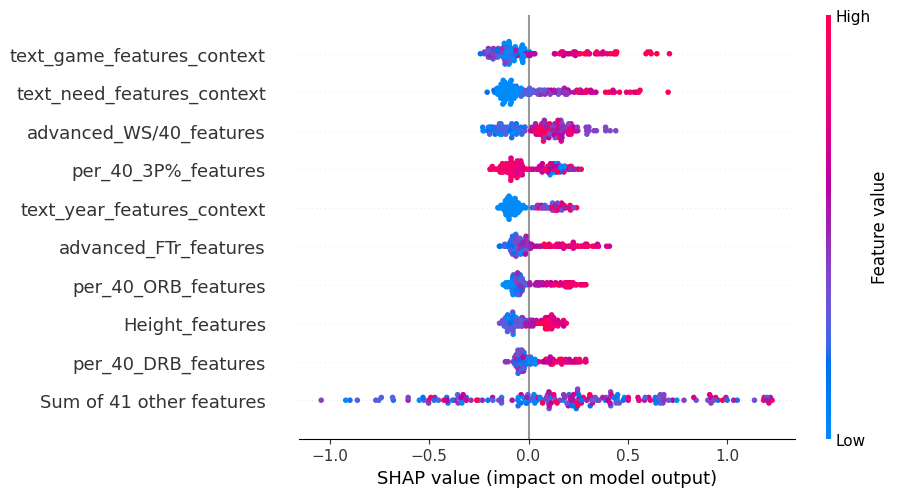

In [38]:
import shap
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

from imblearn.combine import SMOTETomek
sm = SMOTETomek(sampling_strategy = 0.7, random_state=143)
X_resampled, y_resampled = sm.fit_resample(X_train_scaled, y_train)

model = XGBClassifier(learning_rate=0.01,
                        max_depth=7,
                        n_estimators=298,
                        subsample=0.6804196802009144,
                        colsample_bytree=0.6,
                        gamma=0.0,
                        random_state=48)
model.fit(X_resampled, y_resampled)

# =======================
# 6. SHAP sur les données de test (non résamplées)
# =======================
# Important : on utilise X_test_scaled pour une vraie interprétation
explainer = shap.Explainer(model, X_resampled)
shap_values = explainer(X_test_scaled_df)

# =======================
# 7. Beeswarm plot
# =======================
# shap.plots.beeswarm accepte un DataFrame ou numpy array
shap.plots.beeswarm(shap_values, max_display=10)  # Tu peux augmenter ou réduire max_display

In [341]:
import shap
# Calculer les valeurs SHAP
explainer = shap.Explainer(base_pipeline)
shap_values = explainer(X)

# Tracer le beeswarm plot
shap.plots.beeswarm(shap_values, max_display=10)  # max_display limite le nombre de features

c:\Users\Utilisateur\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TypeError: The passed model is not callable and cannot be analyzed directly with the given masker! Model: Pipeline(steps=[('scaler', StandardScaler()),
                ('resampler',
                 SMOTETomek(random_state=143, sampling_strategy=0.7)),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.6, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, fea...ts=None,
                               gamma=0.0, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               

## Do we improve GM's decisions ?

In [350]:
player_names = X_test.index

# Créer un DataFrame avec résultats
results = pd.DataFrame({
    'Player': player_names,
    'Predicted': y_pred,
    'Actual': y_test
})

results['Results'] = results['Predicted'] == results['Actual']

# Afficher les résultats
results

# Filtrer les joueurs prédits comme succès
#successful_players = results[results['Predicted'] == 1]
#print("\nJoueurs prédits comme succès :\n", successful_players)

,Player,Predicted,Actual,Results
player_id,,,,
edmondsumner_18,edmondsumner_18,1,1,True
jordancrawford_11,jordancrawford_11,1,0,False
demarrecarroll_10,demarrecarroll_10,1,1,True
davidstockton_15,davidstockton_15,1,0,False
demarcuscousins_11,demarcuscousins_11,1,1,True
...,...,...,...,...
anthonyedwards_21,anthonyedwards_21,1,1,True
alexlen_14,alexlen_14,1,1,True
dariusgarland_20,dariusgarland_20,1,0,False


In [378]:
mean_salary = 10406572 #Mean salary over two years
mean_profit =  mean_salary*(140588000/12) #Mean profit over two years
results[results['Results']==False]
results['Gain'] = mean_salary
results['loss'] = mean_profit

In [372]:
len(TN)

17

In [379]:
TN = results[(results['Predicted'] == 0) & (results['Actual'] == 0)] 
FN = results[(results['Predicted'] == 0) & (results['Actual'] == 1)] 
TN['Gain'].sum() - FN['loss'].sum()

np.float64(-1097279181340275.9)

In [ ]:
TN Contract - FN Profit

In [ ]:
results[results['Results'] == False]

,Player,Predicted,Actual,Results,Gain,loss
player_id,,,,,,
jordancrawford_11,jordancrawford_11,1,0,False,10406572,1.219199e+14
davidstockton_15,davidstockton_15,1,0,False,10406572,1.219199e+14
ignasbrazdeikis_20,ignasbrazdeikis_20,1,0,False,10406572,1.219199e+14
jamareebouyea_23,jamareebouyea_23,1,0,False,10406572,1.219199e+14
jamelartis_18,jamelartis_18,1,0,False,10406572,1.219199e+14
jamisonbattle_25,jamisonbattle_25,0,1,False,10406572,1.219199e+14
doronlamb_13,doronlamb_13,1,0,False,10406572,1.219199e+14
sharifecooper_22,sharifecooper_22,1,0,False,10406572,1.219199e+14
terrencewilliams_10,terrencewilliams_10,1,0,False,10406572,1.219199e+14
